# GNSS Inversion results

This notebook produces the following plots:
1. The ApRES and GNSS observations, along with the GNSS-constrained inversion results. This plot establishes our ground truth and highlights the differences between the GNSS-constrained predictions and our ApRES observations.
2. The deformation source patterns during peak hydrofracture (determined from peak Northward displacement at G101). This helps establish an understanding of what our simplified scenario should aim to resemble.
3. The timeseries of each inversion component, for each station. This allows us to interpret what deformation is the main contributor to the surface displacements at each station.

In [1]:
# first import libraries, data and helper functions 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import scipy.io
from scipy.signal import detrend

import sys
import os
import time
import xarray as xr
import pickle
import pandas as pd
import cartopy.crs as ccrs
import cartopy as crt
sys.path.append(os.path.abspath('okada_python_scripts/..'))

from okada_python_scripts_streamlined.DC3D import DC3D

The next block loads in the forward strain results, calculated within the notebook fwd_strain_drainage. These results are built around flat-bed inversion results from Larochelle et al. (in prep).

In [2]:
# load Larochelle inversion results
with open("a11_drainage_timeseries.pkl", "rb") as file:
    data_dict=pickle.load(file)
    
dislocations = ["ue", "un", "uz", "uee", "une", "uze", "uen", "unn", "uzn", "uez", "unz", "uzz"]

# Extract time and z
time = data_dict.pop("time")
z = data_dict.pop("z").flatten()
x = data_dict.pop("x")
y = data_dict.pop("y")

# Process all data variables
data_vars = {
    key: (("time", "z", "disl"), np.stack([np.squeeze(d) for d in value], axis=0))
    for key, value in data_dict.items()
}

# Create xarray.Dataset
ds_a11 = xr.Dataset(
    data_vars,
    coords={
        "time": time,
        "z": z,
        "disl": dislocations,
    },
)

with open("a13_drainage_timeseries.pkl", "rb") as file:
    data_dict=pickle.load(file)
    
dislocations = ["ue", "un", "uz", "uee", "une", "uze", "uen", "unn", "uzn", "uez", "unz", "uzz"]

# Extract time and z
time = data_dict.pop("time")
z = data_dict.pop("z").flatten()
x = data_dict.pop("x")
y = data_dict.pop("y")

# Process all data variables
data_vars = {
    key: (("time", "z", "disl"), np.stack([np.squeeze(d) for d in value], axis=0))
    for key, value in data_dict.items()
}

# Create xarray.Dataset
ds_a13 = xr.Dataset(
    data_vars,
    coords={
        "time": time,
        "z": z,
        "disl": dislocations,
    },
)

with open("a14_drainage_timeseries.pkl", "rb") as file:
    data_dict=pickle.load(file)
    
dislocations = ["ue", "un", "uz", "uee", "une", "uze", "uen", "unn", "uzn", "uez", "unz", "uzz"]

# Extract time and z
time = data_dict.pop("time")
z = data_dict.pop("z").flatten()
x = data_dict.pop("x")
y = data_dict.pop("y")

# Process all data variables
data_vars = {
    key: (("time", "z", "disl"), np.stack([np.squeeze(d) for d in value], axis=0))
    for key, value in data_dict.items()
}

# Create xarray.Dataset
ds_a14 = xr.Dataset(
    data_vars,
    coords={
        "time": time,
        "z": z,
        "disl": dislocations,
    },
)


Now we load the data from the GNSS and the ApRES

In [3]:
# GPS
from scipy.io import loadmat

data = loadmat('SQ1X_BHNX_ts_194.75_195.75.mat')

sq11 = {}
sq13 = {}
sq14 = {}
for sq_dict, ind in zip([sq11,sq13,sq14],[0,2,3]):
    for disp in ['east','north','up']:
        sq_dict[disp]=data[f'{disp}_array'][ind].flatten()
    sq_dict['time'] = data['time_array'].flatten()
max_index = np.argmax(sq11['north'])

# ApRES
with open(f'a11_ld_strain.pkl', 'rb') as handle:
    a11_ld = pickle.load(handle)

with open(f'a13_ld_strain.pkl', 'rb') as handle:
    a13_ld = pickle.load(handle)

with open(f'a14_ld_strain.pkl', 'rb') as handle:
    a14_ld = pickle.load(handle)

# Plot 1

/var/folders/q5/9bzlkvcx1glgh6zpxpsqsmm40000gn/T/ipykernel_5240/345466469.py:21: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.5)
/Users/georgelu/anaconda3/envs/glakes_env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/georgelu/anaconda3/envs/glakes_env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/georgelu/anaconda3/envs/glakes_env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


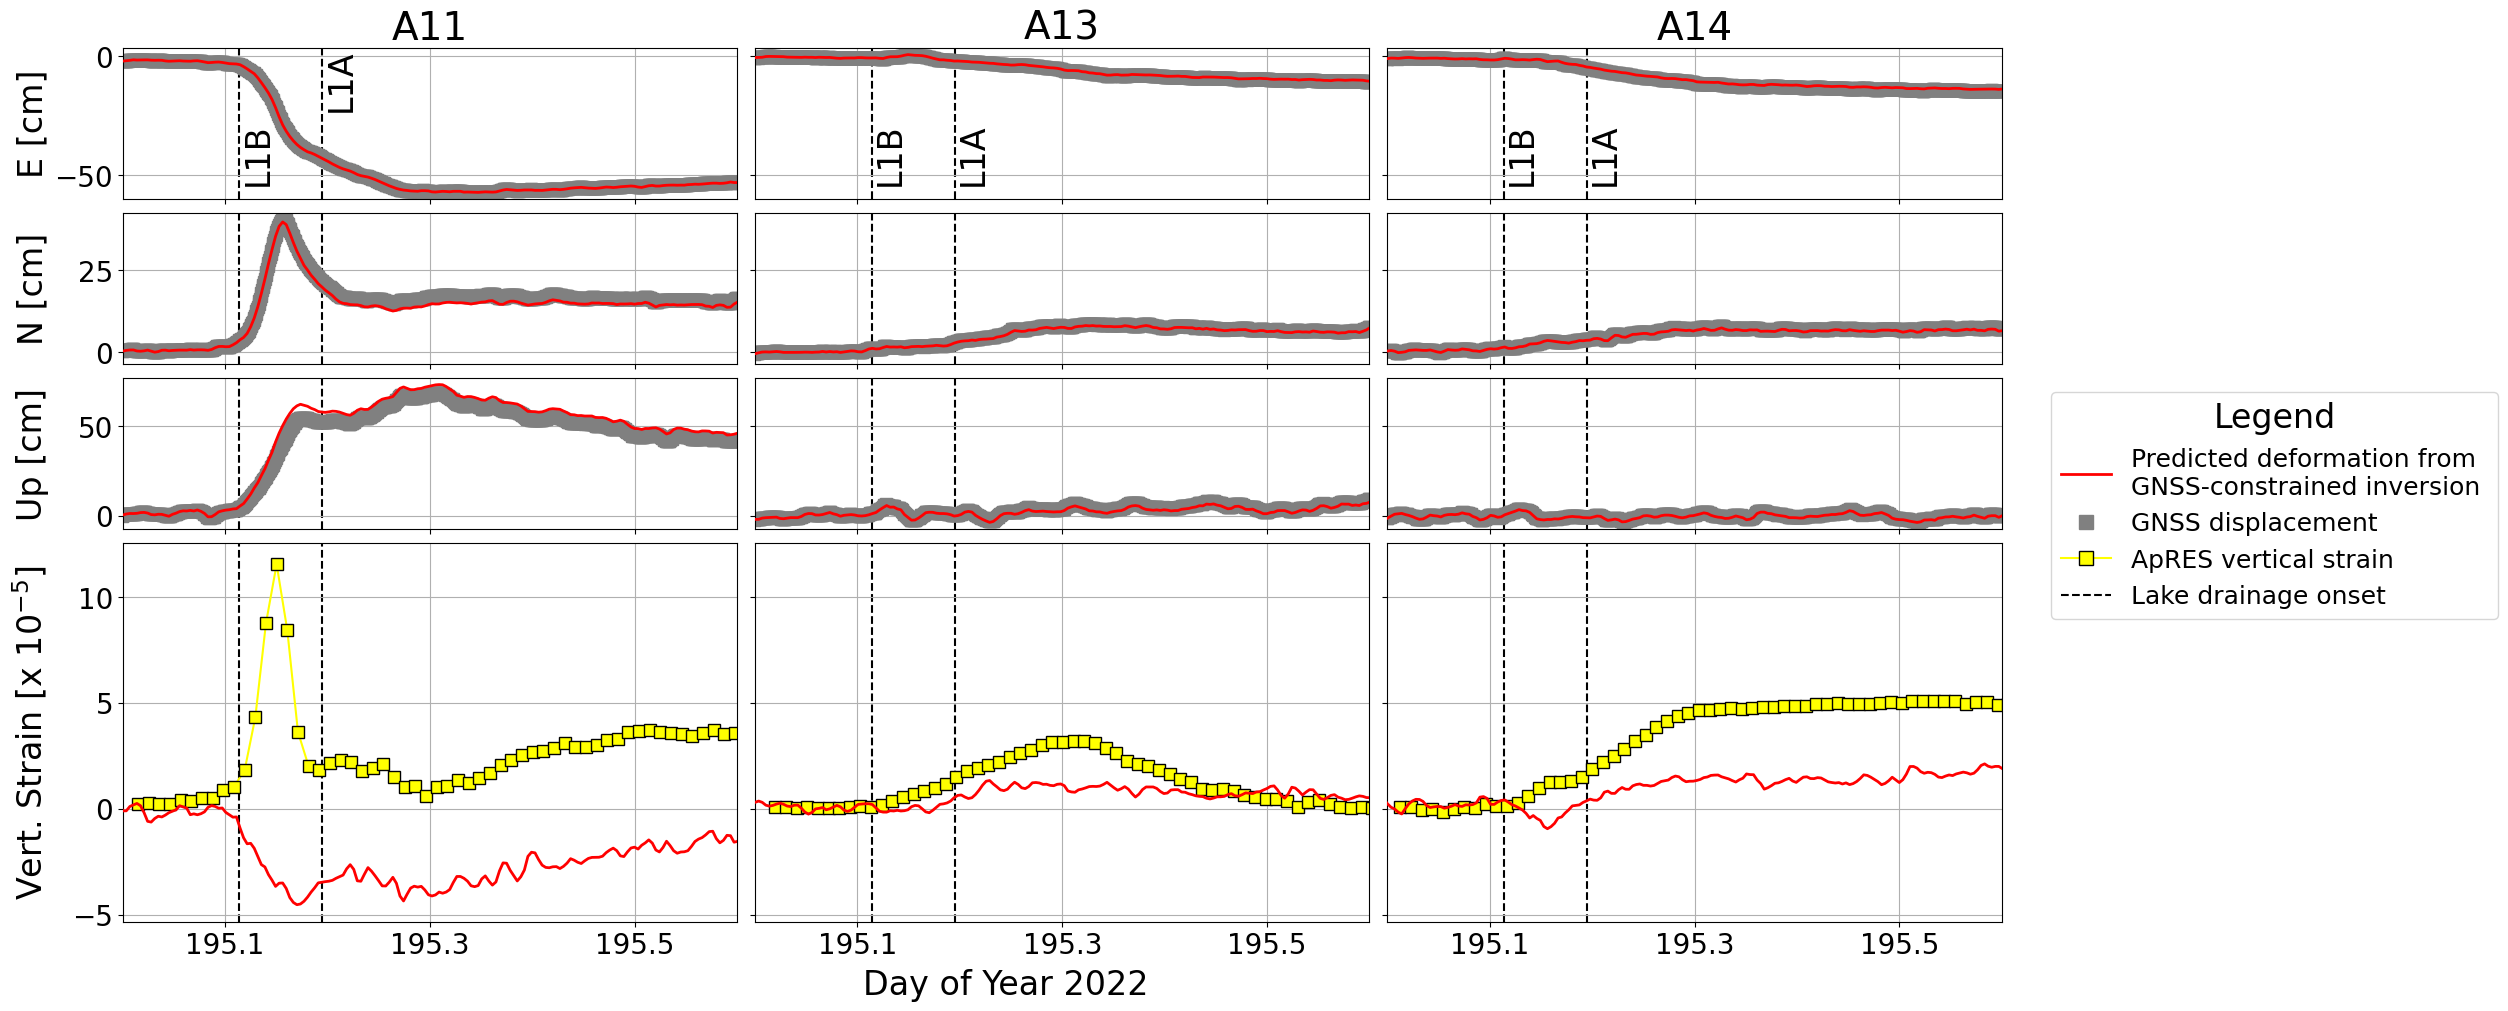

In [4]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

# Set global font sizes
plt.rcParams.update({
    'font.size': 24,
    'axes.titlesize': 28,
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 18,
})

fig, axs = plt.subplots(
    nrows=4, ncols=3, figsize=(20, 10),
    sharex=True, sharey='row',
    layout='constrained',
    gridspec_kw={'height_ratios': [1, 1, 1, 2.5]}
)
plt.subplots_adjust(hspace=0.5)

labels = ['opening', 'slip', 'hf1', 'hf2', 'hf3']
gps_keys = ['east', 'north', 'up']
for i, station, ds, dict_gps, ds_apres in zip(
        [0, 1, 2], ['A11', 'A13', 'A14'],
        [ds_a11, ds_a13, ds_a14],
        [sq11, sq13, sq14],
        [a11_ld, a13_ld, a14_ld]):

    ds['total'] = sum(ds[var] for var in labels)
    ds_surf = ds.sel(z=0)
    mean_500 = ds.sel(disl='uzz').where(ds.z <= 0.5, drop=True)['total'].mean(dim='z')
    std_500 = ds.sel(disl='uzz').where(ds.z <= 0.5, drop=True)['total'].std(dim='z')

    for j, disl, ylabel in zip(
            [0, 1, 2, 3], ['ue', 'un', 'uz', 'uzz'],
            ['East [cm]', 'North [cm]', 'Up [cm]', 'Strain [x10$^{-5}$]']):

        if disl != 'uzz':
            # GNSS marker: gray squares
            axs[j, i].plot(dict_gps['time'], dict_gps[gps_keys[j]] * 100,
                           color='gray', marker='s', linestyle='None',
                           zorder=2, markersize=8)
            # Inversion line: now red
            axs[j, i].plot(ds.time.values, ds_surf.sel(disl=disl)['total'].values,
                           lw=2, color='red', zorder=3)
        else:
            axs[j, i].errorbar(ds_apres.doy_decimal.values,
                               ds_apres.strain.values * 1e5 ,
                               ds_apres.strain_err.values * 1e5,
                               color='yellow', marker='s',
                               markeredgecolor='black', markersize=8, zorder=2)
            axs[j, i].plot(ds.time.values, mean_500.values,
                           lw=2, color='red', zorder=3)

for ax in axs[:, :3].flatten():
    # Vertical dashed lines: keep only first two
    ax.axvline(195.114, color='black', linestyle='--', zorder=1)
    ax.axvline(195.195, color='black', linestyle='--', zorder=1)
    ax.grid()
    ax.set_xlim([195, 195.6])

# Add L1B and L1A text next to dashed lines
for i,ax in enumerate(axs[0]):
    if i==0:
            ax.text(195.195 + 0.002, ax.get_ylim()[1]*0.9, 'L1A', rotation=90, va='top', ha='left')
    else:
            ax.text(195.195 + 0.002, ax.get_ylim()[0]*0.9, 'L1A', rotation=90, va='bottom', ha='left')
    ax.text(195.114 + 0.002, ax.get_ylim()[0]*0.9, 'L1B', rotation=90, va='bottom', ha='left')

column_titles = ['A11', 'A13', 'A14']
for ax, col_title in zip(axs[0], column_titles):
    ax.set_title(col_title)

# Add leftmost column labels
y_labels = ['E [cm]', 'N [cm]', 'Up [cm]', 'Vert. Strain [x 10$^{-5}$]']
for j, label in enumerate(y_labels):
    axs[j, 0].set_ylabel(label, fontsize=24)

# Set custom xticks and labels
xticks = [195.1,  195.3, 195.5]
for ax in axs.flat:
    ax.set_xticks(xticks)
    ax.set_xticklabels([f'{x:.1f}' for x in xticks])

# Add shared x label at the bottom
fig.supxlabel('Day of Year 2022', ha='center', fontsize=24)

# Construct a single shared legend (on the right)
legend_elements = [
    Line2D([0], [0], color='red', lw=2, label='Predicted deformation from\nGNSS-constrained inversion '),
    Line2D([0], [0], color='gray', marker='s', linestyle='None', markersize=10, label='GNSS displacement'),
    Line2D([0], [0], color='yellow', marker='s', linestyle='-',
           markeredgecolor='black', markersize=10, label='ApRES vertical strain'),
     Line2D([0], [0], color='black',linestyle='--',
           label='Lake drainage onset')
]

fig.legend(title='Legend',handles=legend_elements,
           loc='center left',
           bbox_to_anchor=(1.01, 0.5),
           borderaxespad=1,
           frameon=True)
fig.align_labels()


# Plot 2

In [5]:
# load lake geometry
import geopandas as gpd

radius=6378137.0
eccen=0.08181919
lat_true=70
lon_posy=-45
x_origin = -184156.897292208
y_origin = -2323753.59281523

# projection transformation (adapted from https://www.mathworks.com/matlabcentral/fileexchange/32950-polar-stereographic-coordinate-transformation-lat-lon-to-map)
def polarstereo_fwd(phi,lambda_,a,e,phi_c,lambda_0):
    # Convert to radians
    phi = np.deg2rad(phi)
    phi_c = np.deg2rad(phi_c)
    lambda_ = np.deg2rad(lambda_)
    lambda_0 = np.deg2rad(lambda_0)


    # If the standard parallel is in the Southern Hemisphere, switch signs
    if phi_c < 0:
        pm = -1  # Plus or minus, north latitude or south
        phi = -phi
        phi_c = -phi_c
        lambda_ = -lambda_
        lambda_0 = -lambda_0
    else:
        pm = 1

    # This part follows the Snyder projection formula details
    t = np.tan(np.pi / 4 - phi / 2) / ((1 - e * np.sin(phi)) / (1 + e * np.sin(phi)))**(e / 2)
    # Alternative t calculation (commented out in the MATLAB script)
    # t_alt = np.sqrt((1 - np.sin(phi)) / (1 + np.sin(phi)) * ((1 + e * np.sin(phi)) / (1 - e * np.sin(phi)))**e)
    t_c = np.tan(np.pi / 4 - phi_c / 2) / ((1 - e * np.sin(phi_c)) / (1 + e * np.sin(phi_c)))**(e / 2)
    m_c = np.cos(phi_c) / np.sqrt(1 - e**2 * (np.sin(phi_c))**2)
    rho = a * m_c * t / t_c  # True scale at latitude phi_c

    m = np.cos(phi) / np.sqrt(1 - e**2 * (np.sin(phi))**2)
    x = pm * rho * np.sin(lambda_ - lambda_0)
    y = -pm * rho * np.cos(lambda_ - lambda_0)
    k = rho / (a * m)
    return x,y
    
# load the shapefile for L1A

shapefile = gpd.read_file("Lake-L1A-outline.shp")

# Extract coordinates from MultiPoint geometry
x_L1A = []
y_L1A = []

for geom in shapefile.geometry:
    if geom.geom_type == "MultiPoint":  # Ensure it's a MultiPoint object
        for point in geom.geoms:  # Loop through each point
            x_L1A.append(point.x)
            y_L1A.append(point.y)
    elif geom.geom_type == "Point":  # If there are single Point objects
        x_L1A.append(geom.x)
        y_L1A.append(geom.y)

# Convert lists to numpy arrays
x_L1A.append(x_L1A[0])
y_L1A.append(y_L1A[0])
x_L1A = np.array(x_L1A)
y_L1A = np.array(y_L1A)

x_L1A,y_L1A = polarstereo_fwd(y_L1A,x_L1A,radius,eccen,lat_true,lon_posy)

x_L1A = (x_L1A-x_origin)/1000
y_L1A = (y_L1A-y_origin)/1000


# Load the shapefile for L1B
shapefile = gpd.read_file("Lake-L1B-outline.shp")

# Extract coordinates from MultiPoint geometry
x_L1B = []
y_L1B = []

for geom in shapefile.geometry:
    if geom.geom_type == "MultiPoint":  # Ensure it's a MultiPoint object
        for point in geom.geoms:  # Loop through each point
            x_L1B.append(point.x)
            y_L1B.append(point.y)
    elif geom.geom_type == "Point":  # If there are single Point objects
        x_L1B.append(geom.x)
        y_L1B.append(geom.y)

# Convert lists to numpy arrays
x_L1B.append(x_L1B[0])
y_L1B.append(y_L1B[0])

x_L1B = np.array(x_L1B)
y_L1B = np.array(y_L1B)

x_L1B,y_L1B = polarstereo_fwd(y_L1B,x_L1B,radius,eccen,lat_true,lon_posy)

x_L1B = (x_L1B-x_origin)/1000
y_L1B = (y_L1B-y_origin)/1000

def polygon_centroid(x, y):
    """
    Compute the centroid (geometric center) of a closed polygon given its x and y coordinates.

    Parameters:
        x (numpy array): x-coordinates of the polygon vertices.
        y (numpy array): y-coordinates of the polygon vertices.

    Returns:
        tuple: (Cx, Cy) coordinates of the centroid.
    """
    # Ensure the polygon is closed by appending the first point at the end
    if x[0] != x[-1] or y[0] != y[-1]:
        x = np.append(x, x[0])
        y = np.append(y, y[0])

    # Compute the signed area A
    A = 0.5 * np.sum(x[:-1] * y[1:] - x[1:] * y[:-1])

    # Compute centroid coordinates
    Cx = (1 / (6 * A)) * np.sum((x[:-1] + x[1:]) * (x[:-1] * y[1:] - x[1:] * y[:-1]))
    Cy = (1 / (6 * A)) * np.sum((y[:-1] + y[1:]) * (x[:-1] * y[1:] - x[1:] * y[:-1]))

    return Cx, Cy

Cx_L1A, Cy_L1A = polygon_centroid(x_L1A, y_L1A)
Cx_L1B, Cy_L1B = polygon_centroid(x_L1B, y_L1B)

x_a11, y_a11 = polarstereo_fwd(68.7101,-49.55337,radius,eccen,lat_true,lon_posy)
x_a11 = (x_a11 - x_origin)/1000 # convert to km
y_a11 = (y_a11 - y_origin)/1000

x_a13, y_a13 = polarstereo_fwd(68.7424,-49.4929,radius,eccen,lat_true,lon_posy)
x_a13 = (x_a13 - x_origin)/1000 
y_a13 = (y_a13 - y_origin)/1000

x_a14, y_a14 = polarstereo_fwd(68.7406,-49.55671,radius,eccen,lat_true,lon_posy)
x_a14 = (x_a14 - x_origin)/1000 
y_a14 = (y_a14 - y_origin)/1000

In [6]:
# load hydrofracture structures
L = 0.5
W = 0.5
depth = 0.93278072
strike = 184.25
rake = -90

def matstruct_to_dict(matobj):
    data = {}
    for fieldname in matobj._fieldnames:
        elem = getattr(matobj, fieldname)
        if isinstance(elem, scipy.io.matlab.mat_struct):
            data[fieldname] = matstruct_to_dict(elem)  # Recursive call for nested structs
        else:
            data[fieldname] = elem
    return data

file_path = 'HF_distributions_max_L1B_hydro_fracture.mat'  # replace with your file path
mat_contents = scipy.io.loadmat(file_path,struct_as_record=False, squeeze_me=True)
HF1 = matstruct_to_dict(mat_contents['HF'][0])
HF2 = matstruct_to_dict(mat_contents['HF'][1])
HF3 = matstruct_to_dict(mat_contents['HF'][2])
x_surf_ref = mat_contents['x_surf']
y_surf_ref = mat_contents['y_surf']

file_path = 'basal_distributions_flat_bed_time_series.mat'  # replace with your file path
mat_contents = scipy.io.loadmat(file_path,struct_as_record=False, squeeze_me=True)
L_bed = mat_contents['L']
W_bed = mat_contents['W']
dips = mat_contents['dip']
rakes = mat_contents['rake']
strikes = mat_contents['strike']
timesteps_full = scipy.io.loadmat('timesteps.mat')['time'].flatten()
timesteps = timesteps_full

patch_x = mat_contents['x_grid']
patch_y = mat_contents['y_grid']
patch_z = mat_contents['z_grid']


m_arr = mat_contents['m']

HF_1s = []
HF_2s = []
HF_3s = []
openings = []
slides = []
t_max = 576
#print(timesteps[t_max])
m_dict = matstruct_to_dict(m_arr[t_max])
HF_1s.append(m_dict['hf1'])
HF_2s.append(m_dict['hf2'])
HF_3s.append(m_dict['hf3'])
openings.append(np.reshape(m_dict['open'],(patch_x.shape),order='F'))
slides.append(np.reshape(m_dict['slid'],(patch_x.shape),order='F'))
    
HF_1s = np.array(HF_1s)[0]
HF_2s = np.array(HF_2s)[0]
HF_3s = np.array(HF_3s)[0]
openings = np.array(openings)[0]
slides = np.array(slides)[0]


In [7]:
# arrow for flow direction
mean_strike = np.mean(strikes)
mean_rake = np.mean(rakes)

x0, y0 = 0, 0   # arrow starting point
length = 1.0    # arrow length

# Convert angles to radians
strike_rad = np.deg2rad(mean_strike)
rake_rad = np.deg2rad(mean_rake)

# Unit vector along strike
strike_vec = np.array([np.sin(strike_rad), np.cos(strike_rad)])

# Rotate by rake within fault plane (projected to 2D)
rake_vec = (
    np.cos(rake_rad) * strike_vec +
    np.sin(rake_rad) * np.array([-strike_vec[1], strike_vec[0]])  # 90° rotation
)

# Scale rake vector
dx, dy = length * rake_vec

In [8]:
# Function to rotate points by a given strike and dip
def rotate_patch(x, y, z, strike, dip):
    # Convert angles to radians
    strike_rad = np.radians(strike-90)
    dip_rad = np.radians(dip)

    # Rotation matrix for strike (around z-axis)
    R_strike = np.array([[np.cos(strike_rad), np.sin(strike_rad), 0],
                         [-np.sin(strike_rad),  np.cos(strike_rad), 0],
                         [0, 0, 1]])

    # Rotation matrix for dip (around x-axis)
    R_dip = np.array([[1, 0, 0],
                      [0, np.cos(dip_rad), -np.sin(dip_rad)],
                      [0, np.sin(dip_rad),  np.cos(dip_rad)]])

    # Apply rotations
    coords = np.vstack([x, y, z])
    rotated_coords = R_strike @ R_dip @ coords
    return rotated_coords[0], rotated_coords[1], rotated_coords[2]

# Function to create a rectangular patch
def create_patch(center, strike, dip, length=1.0, width=1.0):
    # Local patch vertices (rectangle)
    half_length = length / 2
    half_width = width / 2
    x = np.array([-half_length, half_length, half_length, -half_length])
    y = np.array([-half_width, -half_width, half_width, half_width])
    z = np.zeros(4)  # Flat patch initially

    # Rotate the patch
    x_rot, y_rot, z_rot = rotate_patch(x, y, z, strike, dip)

    # Translate to the center position
    x_rot += center[0]
    y_rot += center[1]
    z_rot += center[2]

    return np.vstack([x_rot, y_rot, z_rot]).T


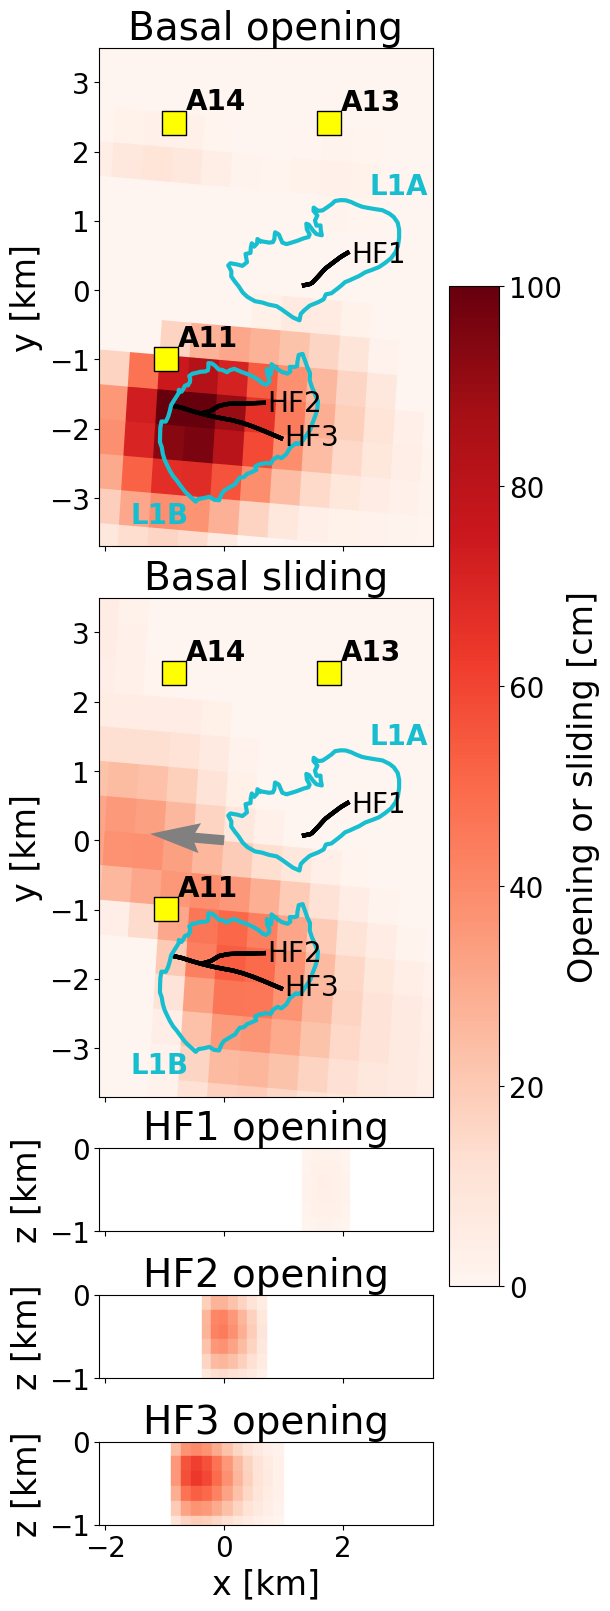

In [9]:
# Plotting
import matplotlib.pyplot as plt
from matplotlib import colors, cm

plt.rcParams.update({
    'font.size': 24,
    'axes.titlesize': 28,
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 28,
    'figure.titlesize': 28,
})

# Create a 5-row plot layout: 2 big, 3 smaller
fig, axs = plt.subplots(5, 1, figsize=(6, 16), constrained_layout=True,
                        sharex=True, 
                        gridspec_kw={'height_ratios': [1.2, 1.2, 0.2, 0.2, 0.2]})

xlim = [-2.1, 3.5]
ylim = [-3.7, 3.5]
zlim = [-1, 0]

norm = colors.Normalize(vmin=0, vmax=100)
cmap = plt.get_cmap('Reds')
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fields = [openings, slides]
titles = ["Basal opening", "Basal sliding"]

hf_data = [(HF1, HF_1s, "HF1 opening"), (HF2, HF_2s, "HF2 opening"), (HF3, HF_3s, "HF3 opening")]
hf_labels = ['HF1', 'HF2', 'HF3']

# Plot maps
for ax, field, title in zip(axs[:2], fields, titles):
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(title)
    ax.set_ylabel('y [km]')

    for i in range(patch_x.shape[0]):
        for j in range(patch_x.shape[1]):
            center = [patch_x[i, j], patch_y[i, j], 0]
            strike_val = strikes[i, j]
            dip_val = 0
            color = cmap(norm(field[i, j] * 100))
            vertices = create_patch(center, strike_val, dip_val, 0.5, 0.5)
            ax.fill(vertices[:, 0], vertices[:, 1], color=color)

    for HF, hf_label in zip([HF1, HF2, HF3], hf_labels):
        for i in range(HF['n']):
            center = [HF['Xl'][i], HF['Yl'][i], -HF['depth'][i]]
            strike_val = HF['strike'][i]
            dip_val = 90
            vertices = create_patch([center[0], center[1], 0], strike_val, dip_val, HF['length'], HF['width'])[:, :2]
            ax.fill(vertices[:, 0], vertices[:, 1], color='black', zorder=3, linewidth=3)
            if i == HF['n'] - 1:
                ax.text(center[0] + 0.1, center[1], hf_label, color='black', fontsize=20,
                        ha='left', va='center', zorder=6)

    ax.plot(x_L1A, y_L1A, color='tab:cyan', zorder=3, linewidth=3)
    ax.plot(x_L1B, y_L1B, color='tab:cyan', zorder=3, linewidth=3)
    ax.text(np.max(x_L1A), np.max(y_L1A), 'L1A', color='tab:cyan', fontsize=20, ha='center', va='bottom', fontweight='bold')
    ax.text(np.min(x_L1B), np.min(y_L1B), 'L1B', color='tab:cyan', fontsize=20, ha='center', va='top', fontweight='bold')

    square_coords = [[x_a11, y_a11], [x_a13, y_a13], [x_a14, y_a14]]
    square_labels = ['A11', 'A13', 'A14']
    for (x, y), label in zip(square_coords, square_labels):
        ax.scatter(x, y, s=300, marker='s', color='yellow', edgecolors='black', zorder=5)
        ax.text(x + 0.2, y + 0.1, label, color='black', fontsize=20,
                ha='left', va='bottom', fontweight='bold', zorder=6)

# Add quiver to 2nd subplot
axs[1].quiver(x0, y0, dx, dy, angles='xy', scale_units='xy', scale=0.8,
              color='gray', width=0.03, zorder=4)

# Plot HF cross sections (bottom 3)
for ax, (HF, values, label) in zip(axs[2:], hf_data):
    ax.set_xlim(xlim)
    ax.set_ylim(zlim)
    ax.set_title(label)
    ax.set_ylabel("z [km]")

    for i in range(HF['n']):
        center = [HF['Xl'][i], HF['Yl'][i], -HF['depth'][i]]
        strike_val = HF['strike'][i]
        dip_val = 90
        color = cmap(norm(values[i] * 100))
        vertices = create_patch(center, strike_val, dip_val, HF['length'], HF['width'])
        ax.fill(vertices[:, 0], vertices[:, 2], color=color)

# Label bottom x-axis
axs[-1].set_xlabel("x [km]")

# Shared colorbar
fig.colorbar(sm, ax=axs, orientation='vertical',
             label='Opening or sliding [cm]')

plt.show()

# Plots 3

## A11

/var/folders/q5/9bzlkvcx1glgh6zpxpsqsmm40000gn/T/ipykernel_5240/2783611090.py:57: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.85)


Text(0.5, 0.01, 'DOY 2022')

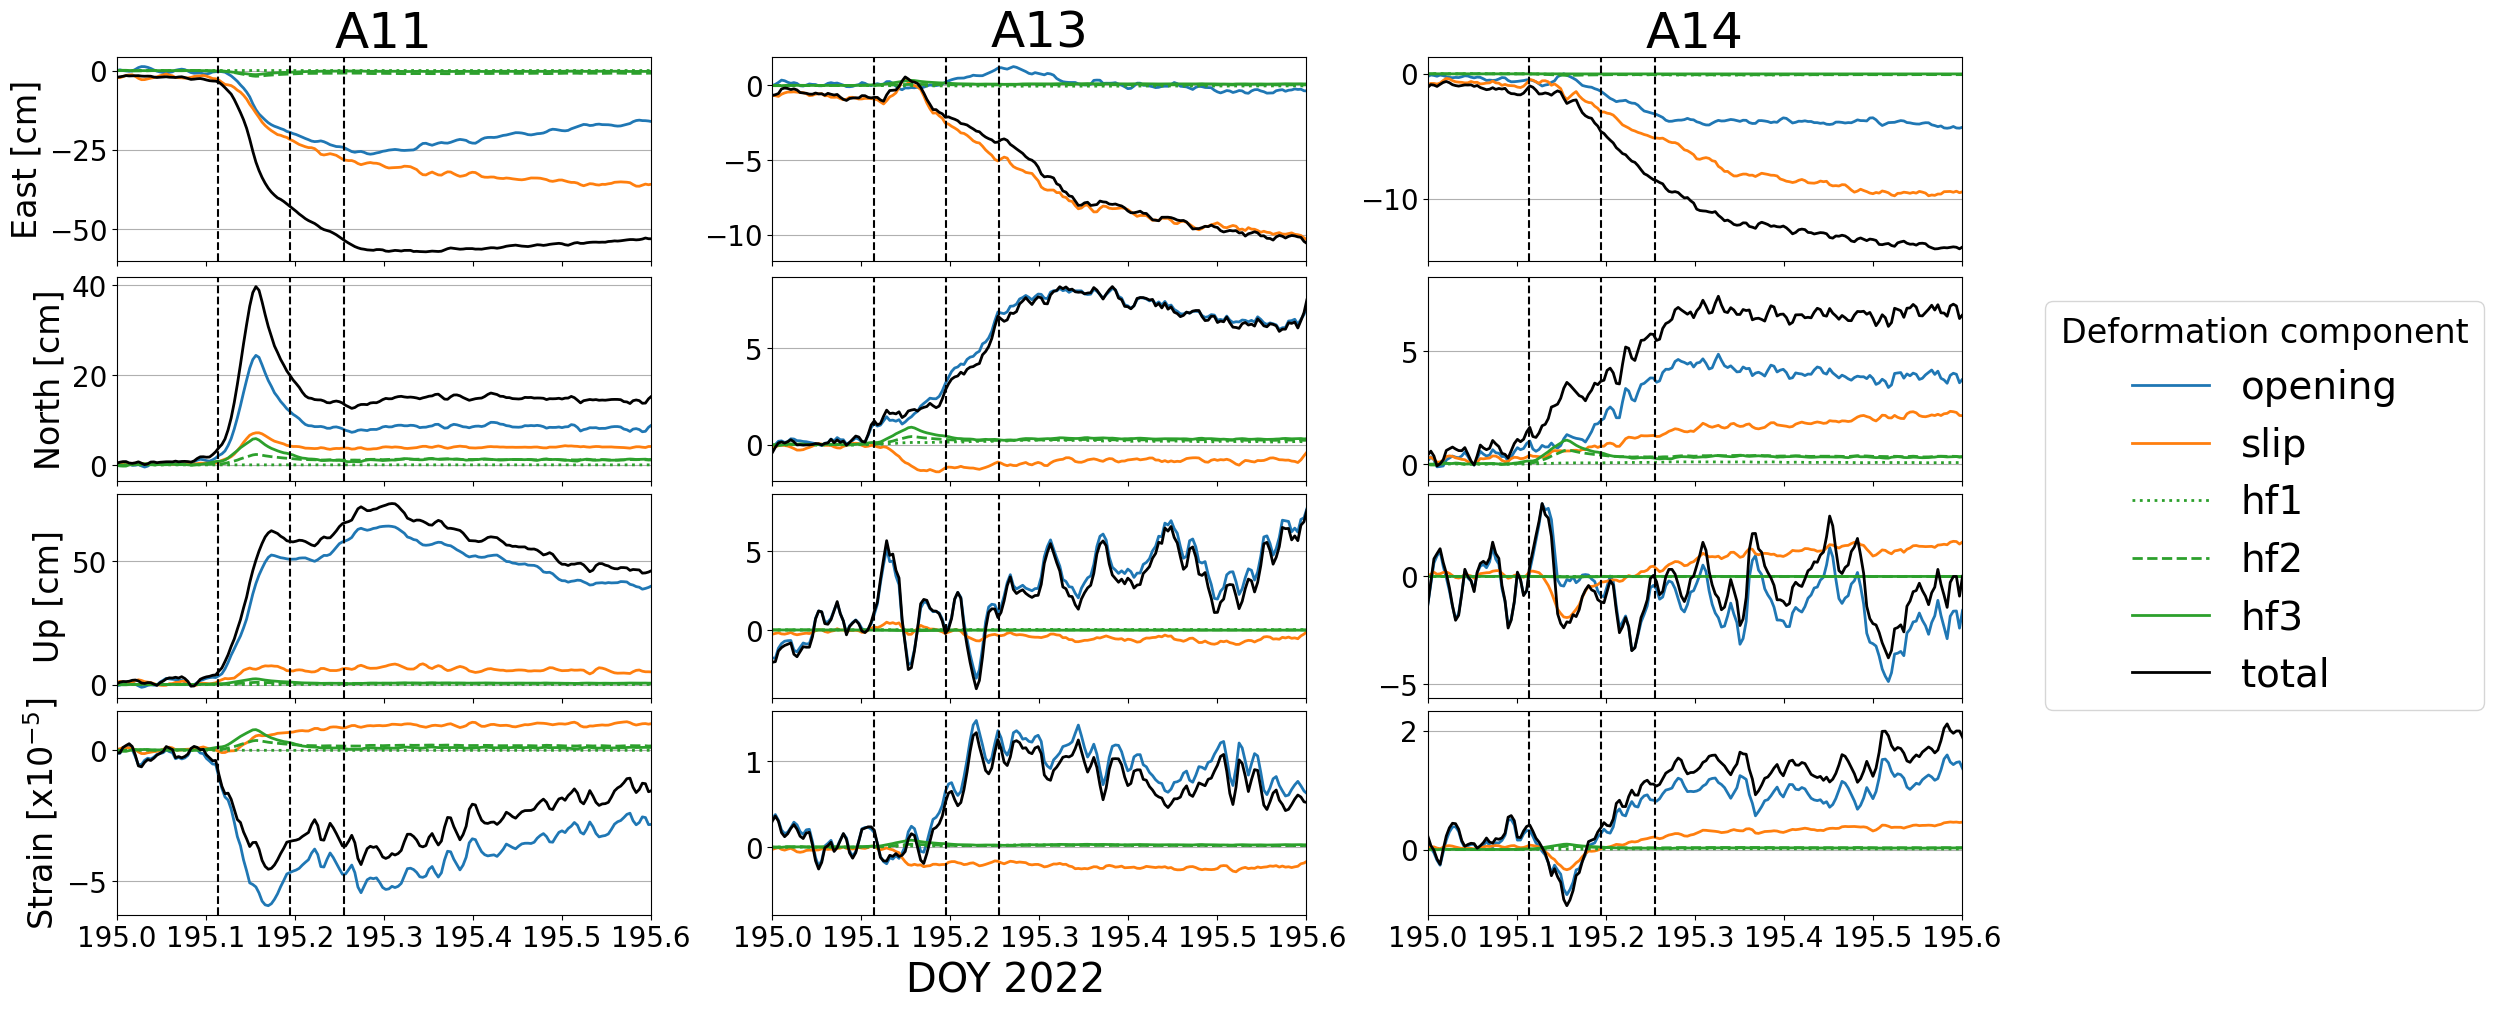

In [10]:
import matplotlib.pyplot as plt

# Set global font sizes
plt.rcParams.update({
    'font.size': 24,          # General font size
    'axes.titlesize': 36,     # Title font size
    'axes.labelsize': 24,     # Axis label font size
    'xtick.labelsize': 20,    # X-axis tick label size
    'ytick.labelsize': 20,    # Y-axis tick label size
    'legend.fontsize': 28,    # Legend font size
    'figure.titlesize': 36,   # Suptitle font size
})

fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(20, 10), sharex=True, layout='constrained')

labels = ['opening', 'slip', 'hf1', 'hf2', 'hf3', 'total']
lines = []
linestyles = ['-','-',':','--','-','-']
linecolors = ['tab:blue','tab:orange','tab:green','tab:green','tab:green','black']
for i, station, ds in zip([0, 1, 2], ['A11', 'A13', 'A14'], [ds_a11, ds_a13, ds_a14]):
    ue = ds.sel(z=0).sel(disl='ue')

    for var,linestyle,linecolor in zip(labels,linestyles,linecolors):
        line, = axs[0, i].plot(ue.time.values, ue[var].values,linestyle=linestyle,color=linecolor,lw=2)
        if i == 0:
            lines.append(line)
    axs[0, i].set_title(station)
    axs[0, 0].set_ylabel('East [cm]')

    un = ds.sel(z=0).sel(disl='un')
    for var,linestyle,linecolor in zip(labels,linestyles,linecolors):
        axs[1, i].plot(un.time.values, un[var].values,linestyle=linestyle,color=linecolor,lw=2)
    axs[1, 0].set_ylabel('North [cm]')

    uz = ds.sel(z=0).sel(disl='uz')
    for var ,linestyle,linecolor in zip(labels,linestyles,linecolors):
        axs[2, i].plot(uz.time.values, uz[var].values,linestyle=linestyle,color=linecolor,lw=2)
    axs[2, 0].set_ylabel('Up [cm]')
    uzz = ds.sel(disl='uzz')
    uzz_top500 = uzz.where(uzz.z <= 0.5, drop=True)
    mean = uzz_top500.mean(dim='z')
    for var,linestyle,linecolor in zip(labels,linestyles,linecolors):
        axs[3, i].plot(mean.time.values, mean[var].values,linestyle=linestyle,color=linecolor,lw=2)
    axs[3, 0].set_ylabel('Strain [x10$^{-5}$]')

for ax in axs[:, :3].flatten():
    ax.axvline(195.114, color='black', linestyle='--')
    ax.axvline(195.195, color='black', linestyle='--')
    ax.axvline(195.255, linestyle='--', color='black')
    ax.grid(axis='y')
    ax.set_xlim([195, 195.6])
labels = ['opening', 'slip', 'hf1', 'hf2', 'hf3', 'total']

fig.legend(lines, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), title='Deformation component')

# Adjust layout to make space for the legend
fig.subplots_adjust(right=0.85)
fig.supxlabel('DOY 2022')